# **Comparacion objetiva de tecnicas de reduccion de dimension**

En la Clase 1 usamos **PCA** para proyectar los digitos a $\mathbb{R}^2$ y visualizarlos. Pero PCA no es la unica opcion: existen muchas tecnicas de *reduccion de dimension* (dimensionality reduction) y *aprendizaje de variedades* (manifold learning).

Una pregunta natural es: **si tengo varias tecnicas, como decido cual es "mejor"?**

Mirar las graficas ayuda, pero es **subjetivo**. En este notebook aprenderemos a **comparar tecnicas de forma objetiva**, usando metricas numericas que cuantifican que tan bien cada proyeccion preserva la estructura de los datos.

**Metas:**
1. Aplicar varias tecnicas (PCA, MDS, Isomap, LLE, t-SNE, UMAP) al mismo conjunto de datos.
2. Entender que significa que una proyeccion sea "buena".
3. Medir la calidad con metricas objetivas y comparar los resultados en una tabla.
4. Ir mas alla de solo *proyectar*: **refinar** el espacio de embeddings (de forma no supervisada y supervisada) con la libreria [`embedding-kit`](https://github.com/fagonzalezo/embedding-kit) y ver si mejora las metricas.

> **Nota:** Este notebook es material complementario. El unico metodo de reduccion de dimension en el temario del curso es PCA; las demas tecnicas se incluyen como extension para poder comparar.

---
### 0. Librerias

Ademas de `numpy`, `matplotlib` y `scikit-learn` (que ya usamos en la Clase 1), usaremos:
- `pandas` para organizar los resultados en una tabla.
- `umap-learn` (opcional). Si no esta instalado, el notebook simplemente lo omite.
- `embedkit` (la libreria [embedding-kit](https://github.com/fagonzalezo/embedding-kit)), para la seccion de **refinamiento**. Tambien es opcional: si no esta, esa seccion se omite.

En Google Colab casi todo viene preinstalado. Si `umap` o `embedkit` no estan disponibles, descomenta las lineas del `pip install`.

In [1]:
# !pip install umap-learn                                   # <- descomenta en Colab si UMAP no esta disponible
# !pip install git+https://github.com/fagonzalezo/embedding-kit  # <- descomenta en Colab para el refinamiento

import time
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Datos y PCA
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Tecnicas de manifold learning
from sklearn.manifold import MDS, Isomap, LocallyLinearEmbedding, TSNE

# Metricas para comparar
from sklearn.manifold import trustworthiness
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

# UMAP es opcional
try:
    import umap
    HAY_UMAP = True
except Exception:
    HAY_UMAP = False
    print("UMAP no esta instalado; se omitira. (Descomenta el pip install de arriba para incluirlo.)")

# embedding-kit (embedkit) es opcional; se usa en la seccion de refinamiento
try:
    from embedkit import EmbedKit, EmbedKitAnalyzer
    HAY_EMBEDKIT = True
except Exception:
    HAY_EMBEDKIT = False
    print("embedkit no esta instalado; la seccion de refinamiento se omitira.")

# Para reproducibilidad
SEED = 0
np.random.seed(SEED)

---
### 1. Los datos

Usamos el mismo conjunto de **digitos** de la Clase 1: 1797 imagenes de 8x8 pixeles, cada una un vector en $\mathbb{R}^{64}$.

Para que las tecnicas mas costosas (como MDS) corran rapido, tomamos una **muestra estratificada** de `N` puntos (misma cantidad por digito). Todas las tecnicas se evaluan sobre *exactamente los mismos puntos*, para que la comparacion sea justa.

In [2]:
digits = load_digits()
X_full = digits.data          # (1797, 64)
y_full = digits.target        # etiqueta (el numero) de cada imagen

# --- Muestra estratificada de N puntos (misma cantidad por clase) ---
N = 800
rng = np.random.RandomState(SEED)
por_clase = N // 10
sel = np.hstack([rng.choice(np.where(y_full == d)[0], por_clase, replace=False)
                 for d in range(10)])
rng.shuffle(sel)

X = X_full[sel]
y = y_full[sel]
print("Forma de los datos que compararemos:", X.shape)
print("Puntos por digito:", por_clase)

Forma de los datos que compararemos: (800, 64)
Puntos por digito: 80


---
### 2. Las tecnicas

Definimos las tecnicas que queremos comparar. Cada una recibe los datos en $\mathbb{R}^{64}$ y devuelve una proyeccion en $\mathbb{R}^2$.

Una idea util para entenderlas:

| Tecnica | Tipo | Que intenta preservar |
|---|---|---|
| **PCA** | Lineal | Las direcciones de mayor varianza (estructura **global**) |
| **MDS** | No lineal | Las **distancias** entre todos los pares de puntos |
| **Isomap** | No lineal | Distancias **geodesicas** sobre la variedad (global) |
| **LLE** | No lineal | La geometria **local** (cada punto como combinacion de sus vecinos) |
| **t-SNE** | No lineal | Los **vecindarios locales** (bueno para ver grupos) |
| **UMAP** | No lineal | Estructura local y algo de la global |

Todas comparten el hiperparametro `n_neighbors` / `perplexity` que controla cuan "local" es el metodo. Lo fijamos a un valor comun para comparar de forma pareja.

In [3]:
K = 10  # numero de vecinos "local" comun para los metodos que lo usan

tecnicas = {
    "PCA":    PCA(n_components=2, random_state=SEED),
    "MDS":    MDS(n_components=2, random_state=SEED, n_init=1,
                  normalized_stress="auto"),
    "Isomap": Isomap(n_components=2, n_neighbors=K),
    "LLE":    LocallyLinearEmbedding(n_components=2, n_neighbors=K,
                                     random_state=SEED),
    "t-SNE":  TSNE(n_components=2, random_state=SEED, init="pca",
                   perplexity=30, learning_rate="auto"),
}
if HAY_UMAP:
    tecnicas["UMAP"] = umap.UMAP(n_components=2, n_neighbors=K, random_state=SEED)

print("Tecnicas a comparar:", list(tecnicas.keys()))

Tecnicas a comparar: ['PCA', 'MDS', 'Isomap', 'LLE', 't-SNE', 'UMAP']


---
### 3. Como medir que una proyeccion es "buena"?

Aqui esta el corazon del notebook. No existe una unica definicion de "buena", asi que usamos **varias metricas complementarias**. Cada una mira un aspecto distinto:

1. **Trustworthiness (confiabilidad)** — Cuando dos puntos aparecen *cerca en 2D*, ¿tambien estaban cerca en $\mathbb{R}^{64}$? Penaliza los **vecinos falsos** (puntos que la proyeccion junto pero que en realidad estaban lejos). Rango $(0,1]$, **mas alto es mejor**.

2. **Continuity (continuidad)** — Lo contrario: cuando dos puntos estaban *cerca en $\mathbb{R}^{64}$*, ¿siguen cerca en 2D? Penaliza los **vecinos rotos**. Rango $(0,1]$, **mas alto es mejor**.

3. **Preservacion de vecinos locales ($k$-NN)** — Entrenamos un clasificador simple ($k$ vecinos mas cercanos) **usando solo la proyeccion 2D** y medimos su exactitud con validacion cruzada. Si los digitos quedaron bien agrupados, un clasificador tonto acierta. Usa las etiquetas, asi que es una medida **supervisada**. **Mas alto es mejor**.

4. **Silhouette (silueta)** — Usando las etiquetas verdaderas como grupos, mide que tan **compactos y separados** quedan los grupos en 2D. Rango $[-1,1]$, **mas alto es mejor**.

5. **Correlacion de distancias (Shepard/Spearman)** — Correlacion de rangos entre las distancias por pares en $\mathbb{R}^{64}$ y en 2D. Mide preservacion de la estructura **global**. Rango $[-1,1]$, **mas alto es mejor**.

6. **Tiempo (s)** — Cuanto tarda. **Mas bajo es mejor.** Importante en la practica.

> Las metricas 1, 2 y 5 son **no supervisadas** (no usan las etiquetas): miden fidelidad geometrica pura. Las metricas 3 y 4 **si usan las etiquetas**: miden que tan util es la proyeccion para separar clases. Un metodo puede ganar en unas y perder en otras — por eso miramos varias.

In [4]:
def evaluar(X_alto, X_bajo, y, k=K):
    # Calcula las metricas de calidad de una proyeccion X_bajo (2D) de X_alto.
    # 1. Trustworthiness: pocos vecinos falsos (bajo 2D -> alto)
    tw = trustworthiness(X_alto, X_bajo, n_neighbors=k)
    # 2. Continuity: pocos vecinos rotos (se obtiene intercambiando argumentos)
    cont = trustworthiness(X_bajo, X_alto, n_neighbors=k)
    # 3. Exactitud de un k-NN entrenado solo con la proyeccion 2D (supervisada)
    knn = KNeighborsClassifier(n_neighbors=k)
    acc = cross_val_score(knn, X_bajo, y, cv=5).mean()
    # 4. Silhouette usando las etiquetas verdaderas como grupos
    sil = silhouette_score(X_bajo, y)
    # 5. Correlacion (Spearman) entre distancias por pares alto-dim vs 2D
    rho = spearmanr(pdist(X_alto), pdist(X_bajo)).correlation
    return {
        "Trustworthiness": tw,
        "Continuity": cont,
        "kNN acc (2D)": acc,
        "Silhouette": sil,
        "Corr. distancias": rho,
    }

---
### 4. Correr las tecnicas clasicas y medirlas

Aplicamos cada tecnica, guardamos la proyeccion 2D, medimos el tiempo y calculamos las metricas. Todo se junta en una tabla (`DataFrame`) para comparar de un vistazo. Mas abajo agregaremos a esta misma tabla las tecnicas de **refinamiento**.

In [5]:
proyecciones = {}
filas = {}

for nombre, modelo in tecnicas.items():
    t0 = time.time()
    X_2d = modelo.fit_transform(X)      # proyeccion a R^2
    dt = time.time() - t0

    proyecciones[nombre] = X_2d
    metricas = evaluar(X, X_2d, y)
    metricas["Tiempo (s)"] = dt
    filas[nombre] = metricas
    print(f"{nombre:8s} listo en {dt:5.2f} s")

tabla = pd.DataFrame(filas).T
tabla

PCA      listo en  0.01 s


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


MDS      listo en  3.17 s


Isomap   listo en  0.15 s


LLE      listo en  0.14 s


t-SNE    listo en  1.97 s


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP     listo en 13.39 s


,Trustworthiness,Continuity,kNN acc (2D),Silhouette,Corr. distancias,Tiempo (s)
PCA,0.833549,0.941128,0.66625,0.122588,0.581372,0.011245
MDS,0.902747,0.946206,0.74875,0.169336,0.730637,3.169701
Isomap,0.884663,0.965205,0.76000,0.187007,0.532712,0.145962
LLE,0.868039,0.944254,0.82375,0.276615,0.318733,0.135846
t-SNE,0.989578,0.984067,0.96750,0.544093,0.507273,1.969897
UMAP,0.984925,0.980486,0.96875,0.634808,0.414088,13.390876


---
### 5. Refinamiento de embeddings con `embedding-kit`

Todas las tecnicas anteriores solo **proyectan** los datos: buscan una transformacion (lineal o no) a $\mathbb{R}^2$. Una idea distinta es **refinar** el espacio de embeddings: entrenar una pequena red neuronal (un *proyector* MLP) que reorganice los datos para que su geometria sea "mas sana" (grupos mas limpios, menos *hubs*, dimension intrinseca mas clara), usando **aprendizaje contrastivo**.

La libreria [`embedding-kit`](https://github.com/fagonzalezo/embedding-kit) (`embedkit`) hace justo esto. Tiene dos piezas:
- **`EmbedKitAnalyzer`**: diagnostica la geometria de un embedding (dimension intrinseca, *hubness*, isotropia, etc.) y **recomienda** como refinarlo.
- **`EmbedKit`**: entrena el proyector contrastivo en dos modos:
  - **`self_supervised`** (*no supervisado*): **no usa etiquetas**. Genera "vistas" aumentadas de cada punto y aprende a acercar las vistas del mismo punto. Mejora la geometria sin saber las clases.
  - **`supervised`**: **usa las etiquetas** `y`. Acerca puntos de la misma clase y aleja los de clases distintas (perdida tipo *SupCon*).

Primero, veamos el diagnostico que produce el analizador sobre nuestros digitos.

In [6]:
if HAY_EMBEDKIT:
    reporte = EmbedKitAnalyzer(k=K).fit(X.astype("float32"))
    reporte.print_summary()
else:
    print("embedkit no disponible: se omite el diagnostico y el refinamiento.")


  EmbedKit Analysis Report  (800 samples × 64 dims)

[Intrinsic Dimension]
  consensus ID     : 7.07  (±7.06)
  TwoNN         : 7.89
  MLE           : 6.21
  lPCA          : 23.00
  MOM           : 6.25

[Hubness]
  k-skewness       : 0.625
  Robin Hood index : -0.317
  hub ratio        : 0.046
  antihub ratio    : 0.010
  hub contamination: 0.200

[Geometry]
  participation_ratio : 13.05
  isotropy_score      : 0.317
  relative_contrast   : 1.405
  neighbor_consistency: 0.991
  uniformity          : -1.1625

[Kernel]
  sigma            : 49.0510
  effective_rank   : 5.82
  spectral_gap     : 13.175
  condition_number : 7.73e+02

[Recommendations]  severity=MEDIUM
  • Moderate intrinsic-to-ambient ratio (ID/D ≈ 0.11): dimensionality reduction may improve downstream tasks.
  • Moderate anisotropy (participation_ratio=13.0): alignment losses or PCA whitening may help.

[Auto-config]
  suggested_k          : 10
  suggested_sigma      : 49.0510
  suggested_target_dim : 11



El analizador sugiere una **dimension objetivo** (`suggested_target_dim`) donde la geometria de los datos "vive" comodamente (para los digitos, alrededor de 10, coherente con la baja dimension intrinseca que estima).

**Como lo integramos a la comparacion.** El proyector contrastivo produce embeddings sobre una *hiperesfera* de esa dimension objetivo, no directamente en 2D. Asi que usamos el refinamiento como un **paso de preprocesamiento** y luego reducimos a 2D con **t-SNE** (nuestra mejor tecnica local), para poder medir y graficar en igualdad de condiciones:

$$\mathbb{R}^{64} \;\xrightarrow{\text{EmbedKit (refina)}}\; \mathbb{R}^{d_{\text{auto}}} \;\xrightarrow{\text{t-SNE}}\; \mathbb{R}^{2}$$

Comparamos entonces:
- **EmbedKit self-sup + t-SNE** (refinamiento **no supervisado**),
- **EmbedKit superv. + t-SNE** (refinamiento **supervisado**),

contra el **t-SNE** aplicado directamente a los datos crudos.

> **Cuidado (importante):** el refinamiento **supervisado** usa las etiquetas `y`, y luego lo evaluamos con metricas que **tambien** usan `y` (exactitud k-NN y silhouette). Por eso sus valores en esas dos columnas seran **optimistas** (hay una forma leve de "hacer trampa": el embedding ya vio las etiquetas). Comparalo sobre todo contra el modo *no supervisado* y contra las metricas que **no** usan etiquetas (trustworthiness, continuity, correlacion de distancias).

In [7]:
def refinar_y_reducir(mode, y=None, epochs=50):
    # Refina R^64 -> R^{d_auto} con EmbedKit y luego reduce a 2D con t-SNE.
    X_ref = EmbedKit(mode=mode, target_dim="auto", epochs=epochs,
                     random_state=SEED).fit_transform(X.astype("float32"), y=y)
    X_ref = np.asarray(X_ref)
    X_2d = TSNE(n_components=2, random_state=SEED, init="pca",
                perplexity=30, learning_rate="auto").fit_transform(X_ref)
    return X_2d, X_ref.shape[1]

if HAY_EMBEDKIT:
    refinamientos = [
        ("EmbedKit self-sup + t-SNE", "self_supervised", None),  # no usa etiquetas
        ("EmbedKit superv. + t-SNE",  "supervised",      y),     # usa etiquetas
    ]
    for nombre, mode, yy in refinamientos:
        t0 = time.time()
        X_2d, d_auto = refinar_y_reducir(mode, y=yy)
        dt = time.time() - t0
        proyecciones[nombre] = X_2d
        metricas = evaluar(X, X_2d, y)
        metricas["Tiempo (s)"] = dt
        filas[nombre] = metricas
        print(f"{nombre}: refinado a dim={d_auto}, listo en {dt:.1f} s")

    tabla = pd.DataFrame(filas).T   # tabla ahora incluye el refinamiento
tabla

EmbedKit self-sup + t-SNE: refinado a dim=11, listo en 5.3 s


EmbedKit superv. + t-SNE: refinado a dim=11, listo en 5.1 s


,Trustworthiness,Continuity,kNN acc (2D),Silhouette,Corr. distancias,Tiempo (s)
PCA,0.833549,0.941128,0.66625,0.122588,0.581372,0.011245
MDS,0.902747,0.946206,0.74875,0.169336,0.730637,3.169701
Isomap,0.884663,0.965205,0.76000,0.187007,0.532712,0.145962
LLE,0.868039,0.944254,0.82375,0.276615,0.318733,0.135846
t-SNE,0.989578,0.984067,0.96750,0.544093,0.507273,1.969897
UMAP,0.984925,0.980486,0.96875,0.634808,0.414088,13.390876
EmbedKit self-sup + t-SNE,0.983844,0.979897,0.94500,0.491229,0.428827,5.310076
EmbedKit superv. + t-SNE,0.931439,0.961504,0.98375,0.810292,0.431323,5.065207


**Como leer la tabla:** para todas las columnas **mas alto es mejor**, excepto **Tiempo (s)** donde mas bajo es mejor.

La siguiente celda resalta, para cada metrica, cual tecnica gana (ahora incluyendo el refinamiento).

In [8]:
def resaltar(col):
    # Verde = mejor. Para el tiempo, "mejor" es el minimo; para el resto, el maximo.
    mejor = col.min() if col.name == "Tiempo (s)" else col.max()
    return ["font-weight: bold; color: green" if v == mejor else "" for v in col]

tabla.style.apply(resaltar).format("{:.3f}")

,Trustworthiness,Continuity,kNN acc (2D),Silhouette,Corr. distancias,Tiempo (s)
PCA,0.834,0.941,0.666,0.123,0.581,0.011
MDS,0.903,0.946,0.749,0.169,0.731,3.170
Isomap,0.885,0.965,0.760,0.187,0.533,0.146
LLE,0.868,0.944,0.824,0.277,0.319,0.136
t-SNE,0.990,0.984,0.968,0.544,0.507,1.970
UMAP,0.985,0.980,0.969,0.635,0.414,13.391
EmbedKit self-sup + t-SNE,0.984,0.980,0.945,0.491,0.429,5.310
EmbedKit superv. + t-SNE,0.931,0.962,0.984,0.810,0.431,5.065


---
### 6. Ver las proyecciones

Los numeros cuentan una parte de la historia; las graficas cuentan la otra. Dibujamos todas las proyecciones lado a lado, coloreadas por digito, para conectar cada metrica con lo que vemos.

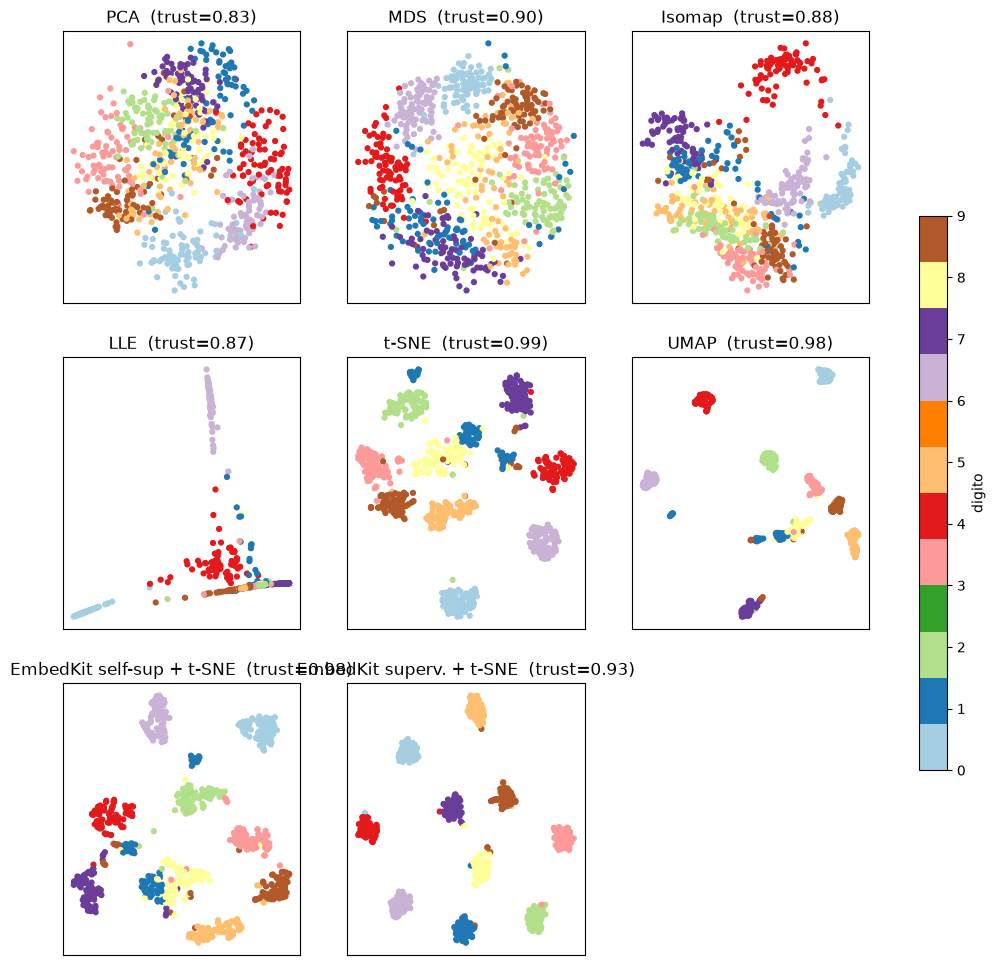

In [9]:
n = len(proyecciones)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (nombre, X_2d) in zip(axes, proyecciones.items()):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="Paired", s=12)
    tw = tabla.loc[nombre, "Trustworthiness"]
    ax.set_title(f"{nombre}  (trust={tw:.2f})")
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[n:]:
    ax.axis("off")

fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label="digito")
plt.show()

---
### 7. Comparar visualmente las metricas

Una grafica de barras por metrica facilita comparar las tecnicas.

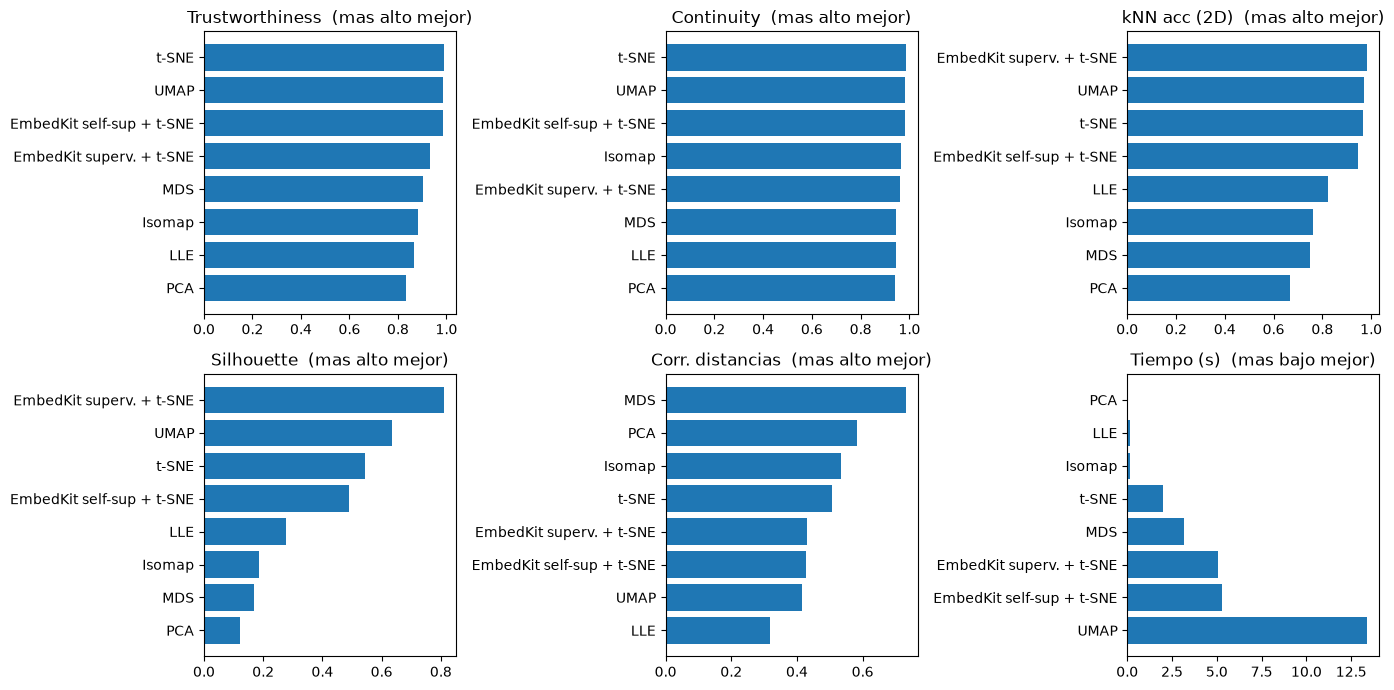

In [10]:
metricas_cols = ["Trustworthiness", "Continuity", "kNN acc (2D)",
                 "Silhouette", "Corr. distancias", "Tiempo (s)"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), metricas_cols):
    orden = tabla[col].sort_values(ascending=(col == "Tiempo (s)"))
    ax.barh(orden.index, orden.values)
    ax.set_title(col + ("  (mas bajo mejor)" if col == "Tiempo (s)"
                         else "  (mas alto mejor)"))
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
### 8. Discusion

**No hay un ganador universal.** Cada tecnica optimiza algo distinto, y eso se refleja en las metricas:

- **PCA** es lineal, rapidisimo y suele ganar en **correlacion de distancias** (preserva bien la estructura *global*), pero al ser lineal mezcla grupos que en realidad son separables.
- **t-SNE** y **UMAP** suelen ganar en **trustworthiness**, **silhouette** y **exactitud k-NN**: separan los grupos muy bien porque se enfocan en lo *local*. A cambio, distorsionan las distancias globales (las distancias entre grupos en un grafico t-SNE **no** son interpretables) y son mas lentos.
- **Isomap** y **MDS** buscan un balance preservando distancias (geodesicas / euclidianas).
- **LLE** preserva la geometria local pero puede colapsar puntos.

**El refinamiento (`embedding-kit`) es una idea distinta:** no solo proyecta, sino que **aprende** una transformacion que mejora la geometria antes de reducir.
- El **refinamiento no supervisado** (self-sup) mejora la separacion de grupos **sin usar etiquetas**, quedando a la par de t-SNE en trustworthiness / k-NN. Util cuando **no** tienes etiquetas pero quieres una geometria mas limpia.
- El **refinamiento supervisado** aprovecha las etiquetas y logra la **mejor separacion de clases** (la silhouette y la exactitud k-NN mas altas). Su costo: necesita etiquetas y, como uso esas mismas etiquetas, sus metricas supervisadas estan **infladas** (recuerda el aviso de la Seccion 5). Nota que en las metricas **no supervisadas** (correlacion de distancias) no domina.

**Moraleja:** "la mejor tecnica" depende de **para que** la quieres:
- ¿Explorar/visualizar **grupos** sin etiquetas? t-SNE, UMAP, o refinamiento self-sup + t-SNE.
- ¿Tienes **etiquetas** y quieres maxima separacion de clases? Refinamiento **supervisado**.
- ¿Preservar **distancias y estructura global**? PCA, MDS, Isomap.
- ¿Datos grandes / velocidad? PCA o UMAP.

Por eso una comparacion **objetiva** reporta **varias metricas**, no una sola, distingue entre metricas **supervisadas y no supervisadas**, y se elige segun el objetivo.

---
### 9. Actividades

**Hacer:**

1. Cambia `K` (por ejemplo a 5 y a 30) y vuelve a correr. ¿Como cambian trustworthiness y la exactitud k-NN? ¿Que tecnica es mas sensible al numero de vecinos?

2. Aumenta `N` (por ejemplo a 1500). ¿Cambia el ranking de las tecnicas? ¿Cual se vuelve muy lenta?

3. Agrega **`StandardScaler`** para estandarizar los datos antes de proyectar (importa de `sklearn.preprocessing`). ¿Mejora alguna metrica? ¿Por que las tecnicas basadas en distancias podrian ser sensibles a la escala?

4. **Refinamiento:** vuelve a correr `EmbedKitAnalyzer` sobre el espacio **refinado** (self-sup) y compara el reporte con el de los datos crudos. ¿Mejoraron indicadores como `k_skewness` (hubness) o `isotropy_score`? Es decir, ¿el refinamiento produjo una geometria "mas sana" como promete?

5. **Refinamiento supervisado justo:** entrena el modo `supervised` usando **solo la mitad** de las etiquetas (pon el resto en un conjunto de prueba) y evalua la exactitud k-NN **solo en la mitad no vista**. ¿El refinamiento supervisado sigue ayudando cuando evitamos el "optimismo" de la Seccion 5?

6. **Conexion con TDA:** una proyeccion "buena" deberia preservar la *forma* (topologia) de los datos, no solo las distancias. Piensa: si dos tecnicas dan la misma trustworthiness pero una rompe un "hueco" (loop) de los datos y la otra no, ¿como podriamos **medir** esa diferencia? (Pista: mas adelante en el curso veremos *homologia persistente*, que compara la forma via *diagramas de persistencia* y distancias entre ellos.)

**Tu respuesta:** *(edita esta celda)*